In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

freq = fetch_openml(name="freMTPL2freq", version=1, as_frame=True)
sev = fetch_openml(name="freMTPL2sev", version=1, as_frame=True)

df_freq = freq.frame
df_sev = sev.frame

print(df_freq.shape)
print(df_freq.head())

(678013, 12)
   IDpol  ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus  \
0    1.0        1      0.10    D         5       0       55          50   
1    3.0        1      0.77    D         5       0       55          50   
2    5.0        1      0.75    B         6       2       52          50   
3   10.0        1      0.09    B         7       0       46          50   
4   11.0        1      0.84    B         7       0       46          50   

  VehBrand     VehGas  Density Region  
0      B12  'Regular'     1217    R82  
1      B12  'Regular'     1217    R82  
2      B12   'Diesel'       54    R22  
3      B12   'Diesel'       76    R72  
4      B12   'Diesel'       76    R72  


In [3]:
# Visão geral da base
print("=== FREQUÊNCIA ===")
print(f"Shape: {df_freq.shape}")
print(df_freq.dtypes)
print("\nEstatísticas descritivas:")
print(df_freq.describe())

print("\n=== SEVERIDADE ===")
print(f"Shape: {df_sev.shape}")
print(df_sev.describe())

# Valores nulos
print("\nValores nulos - Frequência:")
print(df_freq.isnull().sum())

=== FREQUÊNCIA ===
Shape: (678013, 12)
IDpol          float64
ClaimNb          int64
Exposure       float64
Area          category
VehPower         int64
VehAge           int64
DrivAge          int64
BonusMalus       int64
VehBrand      category
VehGas             str
Density          int64
Region        category
dtype: object

Estatísticas descritivas:
              IDpol        ClaimNb       Exposure       VehPower  \
count  6.780130e+05  678013.000000  678013.000000  678013.000000   
mean   2.621857e+06       0.053247       0.528750       6.454631   
std    1.641783e+06       0.240117       0.364442       2.050906   
min    1.000000e+00       0.000000       0.002732       4.000000   
25%    1.157951e+06       0.000000       0.180000       5.000000   
50%    2.272152e+06       0.000000       0.490000       6.000000   
75%    4.046274e+06       0.000000       0.990000       7.000000   
max    6.114330e+06      16.000000       2.010000      15.000000   

              VehAge        Dri

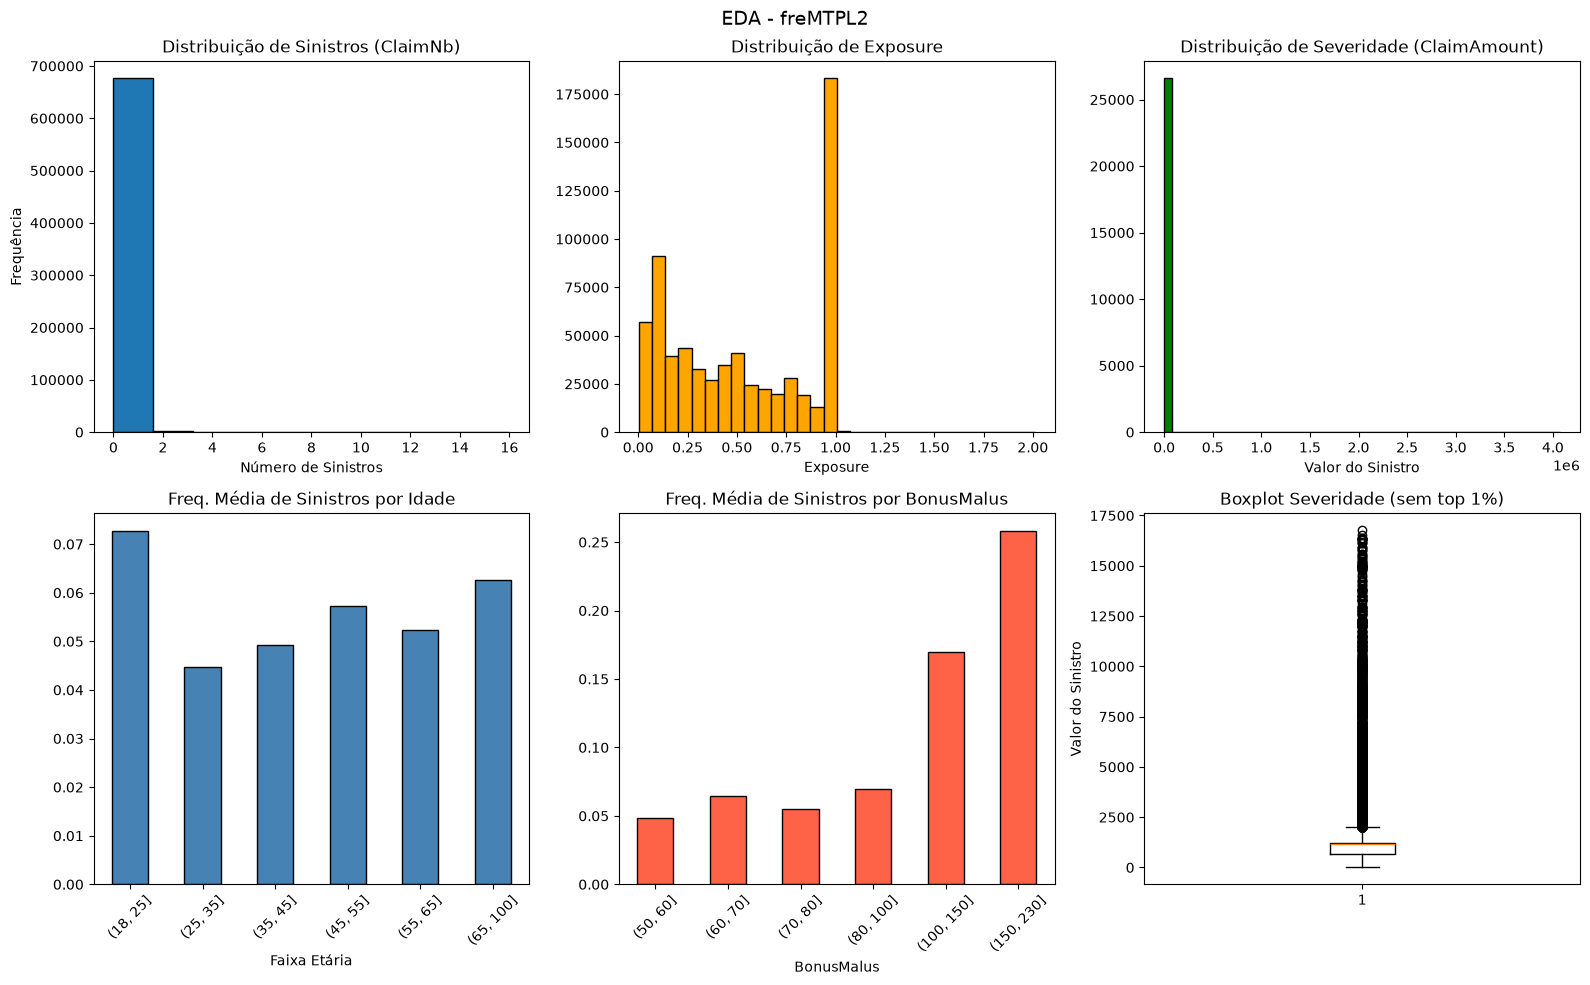

Gráfico salvo!


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA - freMTPL2', fontsize=14)

# 1. Distribuição de sinistros (ClaimNb)
axes[0,0].hist(df_freq['ClaimNb'], bins=10, edgecolor='black')
axes[0,0].set_title('Distribuição de Sinistros (ClaimNb)')
axes[0,0].set_xlabel('Número de Sinistros')
axes[0,0].set_ylabel('Frequência')

# 2. Distribuição de Exposure
axes[0,1].hist(df_freq['Exposure'], bins=30, edgecolor='black', color='orange')
axes[0,1].set_title('Distribuição de Exposure')
axes[0,1].set_xlabel('Exposure')

# 3. Distribuição de severidade (ClaimAmount)
axes[0,2].hist(df_sev['ClaimAmount'], bins=50, edgecolor='black', color='green')
axes[0,2].set_title('Distribuição de Severidade (ClaimAmount)')
axes[0,2].set_xlabel('Valor do Sinistro')

# 4. Sinistros por faixa de idade do motorista
df_freq['DrivAge_bin'] = pd.cut(df_freq['DrivAge'], bins=[18,25,35,45,55,65,100])
sinistros_idade = df_freq.groupby('DrivAge_bin', observed=True)['ClaimNb'].mean()
sinistros_idade.plot(kind='bar', ax=axes[1,0], color='steelblue', edgecolor='black')
axes[1,0].set_title('Freq. Média de Sinistros por Idade')
axes[1,0].set_xlabel('Faixa Etária')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Sinistros por BonusMalus
df_freq['BM_bin'] = pd.cut(df_freq['BonusMalus'], bins=[50,60,70,80,100,150,230])
sinistros_bm = df_freq.groupby('BM_bin', observed=True)['ClaimNb'].mean()
sinistros_bm.plot(kind='bar', ax=axes[1,1], color='tomato', edgecolor='black')
axes[1,1].set_title('Freq. Média de Sinistros por BonusMalus')
axes[1,1].set_xlabel('BonusMalus')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Severidade - boxplot sem outliers extremos
sev_filtrado = df_sev[df_sev['ClaimAmount'] < df_sev['ClaimAmount'].quantile(0.99)]
axes[1,2].boxplot(sev_filtrado['ClaimAmount'])
axes[1,2].set_title('Boxplot Severidade (sem top 1%)')
axes[1,2].set_ylabel('Valor do Sinistro')

plt.tight_layout()
plt.savefig('eda_fremtpl2.png', dpi=150)
plt.show()
print("Gráfico salvo!")

In [5]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

# Preparar base
df_model = df_freq.copy()
df_model['VehGas'] = df_model['VehGas'].str.replace("'", "").str.strip()
df_model['Area'] = df_model['Area'].astype(str)
df_model['VehBrand'] = df_model['VehBrand'].astype(str)
df_model['Region'] = df_model['Region'].astype(str)

# Train/test split
train, test = train_test_split(df_model, test_size=0.2, random_state=42)
print(f"Treino: {train.shape[0]} | Teste: {test.shape[0]}")

# GLM Poisson - Frequência
glm_freq = smf.glm(
    formula='ClaimNb ~ VehPower + VehAge + DrivAge + BonusMalus + Density + Area + VehBrand + VehGas + Region',
    data=train,
    family=sm.families.Poisson(),
    offset=np.log(train['Exposure'])
).fit()

print(glm_freq.summary())

Treino: 542410 | Teste: 135603
                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542367
Model Family:                 Poisson   Df Model:                           42
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1454e+05
Date:                Tue, 16 Jun 2026   Deviance:                   1.7370e+05
Time:                        15:46:02   Pearson chi2:                 1.42e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01072
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Interce

In [6]:
# Preparar base de severidade
df_sev_model = df_sev.merge(
    df_model[['IDpol', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area', 'VehBrand', 'VehGas', 'Region']],
    on='IDpol', how='left'
).dropna()

train_sev, test_sev = train_test_split(df_sev_model, test_size=0.2, random_state=42)
print(f"Treino severidade: {train_sev.shape[0]} | Teste: {test_sev.shape[0]}")

# GLM Gamma - Severidade
glm_sev = smf.glm(
    formula='ClaimAmount ~ VehPower + VehAge + DrivAge + BonusMalus + Density + Area + VehBrand + VehGas + Region',
    data=train_sev,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print(glm_sev.summary())

Treino severidade: 21155 | Teste: 5289
                 Generalized Linear Model Regression Results                  
Dep. Variable:            ClaimAmount   No. Observations:                21155
Model:                            GLM   Df Residuals:                    21112
Model Family:                   Gamma   Df Model:                           42
Link Function:                    Log   Scale:                          48.917
Method:                          IRLS   Log-Likelihood:            -2.2932e+05
Date:                Tue, 16 Jun 2026   Deviance:                       35175.
Time:                        15:46:28   Pearson chi2:                 1.03e+06
No. Iterations:                    68   Pseudo R-squ. (CS):           0.003125
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predições no conjunto de teste
test_copy = test.copy()

# Frequência predita
freq_pred = glm_freq.predict(test_copy)

# Severidade predita (usando variáveis do test de frequência)
sev_pred = glm_sev.predict(test_copy)

# Prêmio puro = frequência x severidade
test_copy['freq_pred'] = freq_pred
test_copy['sev_pred'] = sev_pred
test_copy['premio_puro_pred'] = freq_pred * sev_pred

# Prêmio puro real (para quem teve sinistro)
df_real = test_copy.merge(df_sev[['IDpol', 'ClaimAmount']], on='IDpol', how='left')
df_real['ClaimAmount'] = df_real['ClaimAmount'].fillna(0)
df_real['premio_puro_real'] = df_real['ClaimNb'] * df_real['ClaimAmount']

# Métricas de frequência
mse_freq = mean_squared_error(test_copy['ClaimNb'], freq_pred)
mae_freq = mean_absolute_error(test_copy['ClaimNb'], freq_pred)

# Métricas de severidade (apenas sinistros ocorridos)
test_sev_real = test_sev.copy()
sev_pred_test = glm_sev.predict(test_sev_real)
mse_sev = mean_squared_error(test_sev_real['ClaimAmount'], sev_pred_test)
mae_sev = mean_absolute_error(test_sev_real['ClaimAmount'], sev_pred_test)

print("=== MÉTRICAS GLM ===")
print(f"\nFrequência (Poisson):")
print(f"  MSE:  {mse_freq:.6f}")
print(f"  MAE:  {mae_freq:.6f}")
print(f"  Deviance: {glm_freq.deviance:.2f}")

print(f"\nSeveridade (Gamma):")
print(f"  MSE:  {mse_sev:.2f}")
print(f"  MAE:  {mae_sev:.2f}")
print(f"  Deviance: {glm_sev.deviance:.2f}")

print(f"\nPrêmio Puro Médio Predito: {test_copy['premio_puro_pred'].mean():.2f}")
print(f"Prêmio Puro Médio Real:    {df_real['premio_puro_real'].mean():.2f}")

=== MÉTRICAS GLM ===

Frequência (Poisson):
  MSE:  0.061417
  MAE:  0.149305
  Deviance: 173695.23

Severidade (Gamma):
  MSE:  87384349.09
  MAE:  2049.26
  Deviance: 35175.05

Prêmio Puro Médio Predito: 247.54
Prêmio Puro Médio Real:    99.88


In [9]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

# Preparar features
features = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area', 'VehBrand', 'VehGas', 'Region']
cat_cols = ['Area', 'VehBrand', 'VehGas', 'Region']

def encode_cats(df, cols):
    df = df.copy()
    for col in cols:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    return df

train_enc = encode_cats(train, cat_cols)
test_enc = encode_cats(test, cat_cols)
train_sev_enc = encode_cats(train_sev, cat_cols)
test_sev_enc = encode_cats(test_sev, cat_cols)

# XGBoost Frequência
xgb_freq = xgb.XGBRegressor(
    objective='count:poisson',
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
xgb_freq.fit(
    train_enc[features], train_enc['ClaimNb'],
    sample_weight=train_enc['Exposure'],
    eval_set=[(test_enc[features], test_enc['ClaimNb'])],
    verbose=50
)

# XGBoost Severidade
xgb_sev = xgb.XGBRegressor(
    objective='reg:gamma',
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
xgb_sev.fit(
    train_sev_enc[features], train_sev_enc['ClaimAmount'],
    eval_set=[(test_sev_enc[features], test_sev_enc['ClaimAmount'])],
    verbose=50
)

# Métricas XGBoost
xgb_freq_pred = xgb_freq.predict(test_enc[features])
xgb_sev_pred = xgb_sev.predict(test_sev_enc[features])

mse_freq_xgb = mean_squared_error(test_enc['ClaimNb'], xgb_freq_pred)
mae_freq_xgb = mean_absolute_error(test_enc['ClaimNb'], xgb_freq_pred)
mse_sev_xgb = mean_squared_error(test_sev_enc['ClaimAmount'], xgb_sev_pred)
mae_sev_xgb = mean_absolute_error(test_sev_enc['ClaimAmount'], xgb_sev_pred)

print("\n=== MÉTRICAS XGBoost ===")
print(f"\nFrequência:")
print(f"  MSE: {mse_freq_xgb:.6f}")
print(f"  MAE: {mae_freq_xgb:.6f}")
print(f"\nSeveridade:")
print(f"  MSE: {mse_sev_xgb:.2f}")
print(f"  MAE: {mae_sev_xgb:.2f}")

print("\n=== COMPARAÇÃO FINAL ===")
print(f"{'Métrica':<25} {'GLM':>12} {'XGBoost':>12}")
print(f"{'Freq MSE':<25} {mse_freq:>12.6f} {mse_freq_xgb:>12.6f}")
print(f"{'Freq MAE':<25} {mae_freq:>12.6f} {mae_freq_xgb:>12.6f}")
print(f"{'Sev MSE':<25} {mse_sev:>12.2f} {mse_sev_xgb:>12.2f}")
print(f"{'Sev MAE':<25} {mae_sev:>12.2f} {mae_sev_xgb:>12.2f}")

[0]	validation_0-poisson-nloglik:0.21275
[50]	validation_0-poisson-nloglik:0.20892
[100]	validation_0-poisson-nloglik:0.20807
[150]	validation_0-poisson-nloglik:0.20736
[199]	validation_0-poisson-nloglik:0.20689
[0]	validation_0-gamma-deviance:1.52720
[50]	validation_0-gamma-deviance:1.56304
[100]	validation_0-gamma-deviance:1.60839
[150]	validation_0-gamma-deviance:1.61927
[199]	validation_0-gamma-deviance:1.65346

=== MÉTRICAS XGBoost ===

Frequência:
  MSE: 0.056089
  MAE: 0.111770

Severidade:
  MSE: 87647017.40
  MAE: 1707.23

=== COMPARAÇÃO FINAL ===
Métrica                            GLM      XGBoost
Freq MSE                      0.061417     0.056089
Freq MAE                      0.149305     0.111770
Sev MSE                    87384349.09  87647017.40
Sev MAE                        2049.26      1707.23


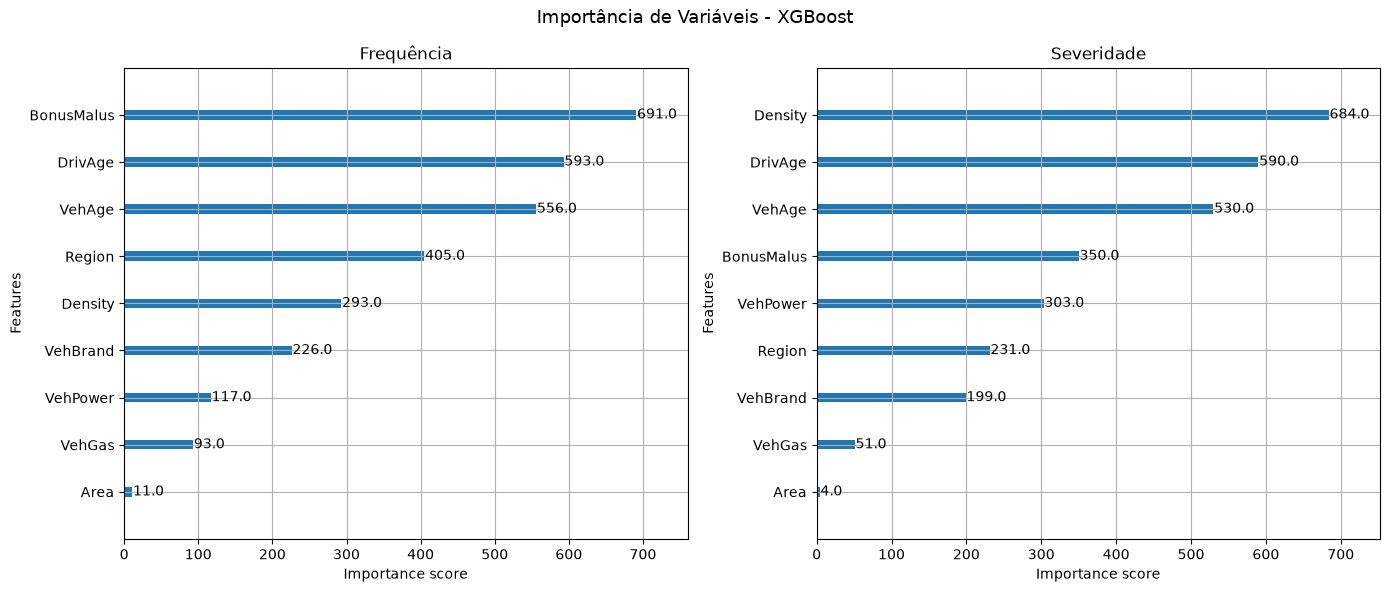


=== RESUMO PARA O TCC ===

Frequência de Sinistros:
  GLM Poisson  → MSE: 0.061417 | MAE: 0.149305
  XGBoost      → MSE: 0.056089 | MAE: 0.111770
  Ganho XGBoost: MSE 8.7% melhor | MAE 25.1% melhor

Severidade de Sinistros:
  GLM Gamma    → MSE: 87384349.09 | MAE: 2049.26
  XGBoost      → MSE: 87647017.40 | MAE: 1707.23
  Ganho XGBoost: MSE -0.3% | MAE 16.7% melhor


In [10]:
# Importância de variáveis XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Importância de Variáveis - XGBoost', fontsize=13)

# Frequência
xgb.plot_importance(xgb_freq, ax=axes[0], max_num_features=10, title='Frequência')

# Severidade
xgb.plot_importance(xgb_sev, ax=axes[1], max_num_features=10, title='Severidade')

plt.tight_layout()
plt.savefig('importancia_variaveis.png', dpi=150)
plt.show()

# Tabela comparativa final formatada
print("\n=== RESUMO PARA O TCC ===")
print(f"\nFrequência de Sinistros:")
print(f"  GLM Poisson  → MSE: {mse_freq:.6f} | MAE: {mae_freq:.6f}")
print(f"  XGBoost      → MSE: {mse_freq_xgb:.6f} | MAE: {mae_freq_xgb:.6f}")
print(f"  Ganho XGBoost: MSE {((mse_freq - mse_freq_xgb)/mse_freq*100):.1f}% melhor | MAE {((mae_freq - mae_freq_xgb)/mae_freq*100):.1f}% melhor")

print(f"\nSeveridade de Sinistros:")
print(f"  GLM Gamma    → MSE: {mse_sev:.2f} | MAE: {mae_sev:.2f}")
print(f"  XGBoost      → MSE: {mse_sev_xgb:.2f} | MAE: {mae_sev_xgb:.2f}")
print(f"  Ganho XGBoost: MSE {((mse_sev - mse_sev_xgb)/mse_sev*100):.1f}% | MAE {((mae_sev - mae_sev_xgb)/mae_sev*100):.1f}% melhor")

In [11]:
import sys
import pandas as pd
import sklearn
import statsmodels
import xgboost
import matplotlib

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("statsmodels:", statsmodels.__version__)
print("xgboost:", xgboost.__version__)
print("matplotlib:", matplotlib.__version__)

Python: 3.13.5
pandas: 3.0.3
scikit-learn: 1.9.0
statsmodels: 0.14.6
xgboost: 3.2.0
matplotlib: 3.11.0
